In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from typing import List, Tuple

# **Load Data**

In [2]:
file_path = "../data/names.txt"

with open(file_path, "r") as f:
    data = f.read()

print(data[:100])

emma
olivia
ava
isabella
sophia
charlotte
mia
amelia
harper
evelyn
abigail
emily
elizabeth
mila
ella


In [3]:
# names are separated by newlines
data[-30:]

'\nzylas\nzyran\nzyrie\nzyron\nzzyzx'

In [4]:
names = data.split('\n')
print("Number of names:", len(names))
names[:10]

Number of names: 32033


['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [5]:
name_lengths = [len(n) for n in names]
print("Minimim length of names:", min(name_lengths))
print("Maximum length of names:", max(name_lengths))
print("Mean length of names:", sum(name_lengths)/len(name_lengths))

Minimim length of names: 2
Maximum length of names: 15
Mean length of names: 6.122217712983486


# **Generate N-Grams**

In [6]:
def generate_ngrams(inp_s, ngram_cnt):
    s = ['.'] + list(inp_s) + ['.']
    s_length = len(s)
    arr_ngrams = []
    for i in range(0, s_length-ngram_cnt+1, 1):
        arr_ngrams.append(tuple(s[i:i+ngram_cnt]))
    return arr_ngrams


# Generate bigrams in the below name:
ngram_cnt = 2
sample_name = names[3]
sample_ngrams = generate_ngrams(sample_name, ngram_cnt)
# sample_ngrams = generate_ngrams("teddy", 4)
print("Sample_Name:", sample_name)
print(f"{ngram_cnt}-grams for {sample_name}:\n{sample_ngrams}")

Sample_Name: isabella
2-grams for isabella:
[('.', 'i'), ('i', 's'), ('s', 'a'), ('a', 'b'), ('b', 'e'), ('e', 'l'), ('l', 'l'), ('l', 'a'), ('a', '.')]


In [7]:
print('Alternative way to generating ngrams')

print('-'*50)
print(sample_name[:])
print(sample_name[1:])

for a, b in zip(sample_name[:], sample_name[1:]):
    print(a,b)

print('-'*50)
print(sample_name[:])
print(sample_name[1:])
print(sample_name[2:])

for a, b, c in zip(sample_name[:], sample_name[1:], sample_name[2:]):
    print(a,b,c)

Alternative way to generating ngrams
--------------------------------------------------
isabella
sabella
i s
s a
a b
b e
e l
l l
l a
--------------------------------------------------
isabella
sabella
abella
i s a
s a b
a b e
b e l
e l l
l l a


In [8]:
def generate_ngrams_v2(inp_s, ngram_cnt):
    s = ['.'] + list(inp_s) + ['.']
    shifts = []
    for i in range(0, ngram_cnt):
        shifts.append(s[i:])
    
    # return [''.join(tup) for tup in list(zip(*shifts))]
    return list(zip(*shifts))


# Generate bigrams in the below name:
ngram_cnt = 3
sample_name = names[3]
sample_ngrams_v2 = generate_ngrams_v2(sample_name, ngram_cnt)
# sample_ngrams_v2 = generate_ngrams_v2("teddy", 4)
print("Sample_Name:", sample_name)
print(f"{ngram_cnt}-grams for {sample_name}:\n{sample_ngrams_v2}")

Sample_Name: isabella
3-grams for isabella:
[('.', 'i', 's'), ('i', 's', 'a'), ('s', 'a', 'b'), ('a', 'b', 'e'), ('b', 'e', 'l'), ('e', 'l', 'l'), ('l', 'l', 'a'), ('l', 'a', '.')]


# **Statistics: Count of occurence of each N-Gram**

In [9]:
names[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [10]:
def get_ngram_stats(lst_s:list, ngram_cnt:int)->dict:
    ngram_stats = {}
    for s in lst_s:
        arr_ngram_s = generate_ngrams_v2(s, ngram_cnt)
        for tup in arr_ngram_s:
            ngram_stats[tup] = ngram_stats.get(tup, 0) + 1
    return ngram_stats


# Get bi-gram stats
list_of_names = names[:]
ngram_cnt=2
bigram_stats = get_ngram_stats(list_of_names, ngram_cnt)
for k, v in bigram_stats.items():
    print(f"{k}: {v}")

('.', 'e'): 1531
('e', 'm'): 769
('m', 'm'): 168
('m', 'a'): 2590
('a', '.'): 6640
('.', 'o'): 394
('o', 'l'): 619
('l', 'i'): 2480
('i', 'v'): 269
('v', 'i'): 911
('i', 'a'): 2445
('.', 'a'): 4410
('a', 'v'): 834
('v', 'a'): 642
('.', 'i'): 591
('i', 's'): 1316
('s', 'a'): 1201
('a', 'b'): 541
('b', 'e'): 655
('e', 'l'): 3248
('l', 'l'): 1345
('l', 'a'): 2623
('.', 's'): 2055
('s', 'o'): 531
('o', 'p'): 95
('p', 'h'): 204
('h', 'i'): 729
('.', 'c'): 1542
('c', 'h'): 664
('h', 'a'): 2244
('a', 'r'): 3264
('r', 'l'): 413
('l', 'o'): 692
('o', 't'): 118
('t', 't'): 374
('t', 'e'): 716
('e', '.'): 3983
('.', 'm'): 2538
('m', 'i'): 1256
('a', 'm'): 1634
('m', 'e'): 818
('.', 'h'): 874
('r', 'p'): 14
('p', 'e'): 197
('e', 'r'): 1958
('r', '.'): 1377
('e', 'v'): 463
('v', 'e'): 568
('l', 'y'): 1588
('y', 'n'): 1826
('n', '.'): 6763
('b', 'i'): 217
('i', 'g'): 428
('g', 'a'): 330
('a', 'i'): 1650
('i', 'l'): 1345
('l', '.'): 1314
('y', '.'): 2007
('i', 'z'): 277
('z', 'a'): 860
('e', 't'): 58

In [11]:
# Top-k Frequently occuring bi-grams
sorted(list(bigram_stats.items()), key=lambda kv: -kv[1])[:10]

[(('n', '.'), 6763),
 (('a', '.'), 6640),
 (('a', 'n'), 5438),
 (('.', 'a'), 4410),
 (('e', '.'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('.', 'k'), 2963)]

In [12]:
# Create character to integer lookup table

# Create 2D matrix for bi-gram stats
# Rows        : 1st character in bi-gram
# Columns     : 2nd Character in bigram
# Matrix Cell : Stores frequency of occurence of a bigram -> column term being followed by row term


# Generalizing for n-gram stats:
# For bigram model: we will have a 27 X 27 matrix where 27 is the unique chars in our vocab
# For trigram model: we will have a 27 X 27 X 27 tensor -> For each 27 chars, we have a bigram matrix (27 X 27)

In [13]:
# Bidirectional Lookup
set_unique_chars = (set(''.join(names)))
set_unique_chars.add('.')
lst_unique_chars = sorted(list(set_unique_chars))
stoi = {s:i for i, s in enumerate(lst_unique_chars)}
itos = {i:s for s,i in stoi.items()}

In [14]:
# Generate Ndim count tensor for ngram model
def get_ngram_cnt_tensor(lst_s:list, ngram_cnt:int, stoi:dict)->torch.tensor:
    # Shape of ngram tensor
    ngram_tensor_shape = (len(stoi),)*ngram_cnt
    N = torch.zeros(ngram_tensor_shape, dtype=torch.int32)

    for s in lst_s:
        arr_ngram_s = generate_ngrams_v2(s, ngram_cnt)
        for tup in arr_ngram_s:
            # print(tup)
            # Iterate through each ngram tuple and make index for ngram tensor
            tup_idx=0
            N_idx = []
            while tup_idx<len(tup):
                N_idx.append(stoi[tup[tup_idx]])
                # print(stoi[tup[tup_idx]])
                tup_idx+=1
            # print(N_idx)

            # Increase cnt of N[N_idx] by 1
            N[tuple(N_idx)]+=1

    return N


list_of_names = names[:]
ngram_cnt=2
bigram_cnt_tensor = get_ngram_cnt_tensor(list_of_names, ngram_cnt, stoi)
ngram_cnt=3
trigram_cnt_tensor = get_ngram_cnt_tensor(list_of_names, ngram_cnt, stoi)

print("bigram_cnt_tensor.shape:", bigram_cnt_tensor.shape)
print("trigram_cnt_tensor.shape", trigram_cnt_tensor.shape)

bigram_cnt_tensor.shape: torch.Size([27, 27])
trigram_cnt_tensor.shape torch.Size([27, 27, 27])


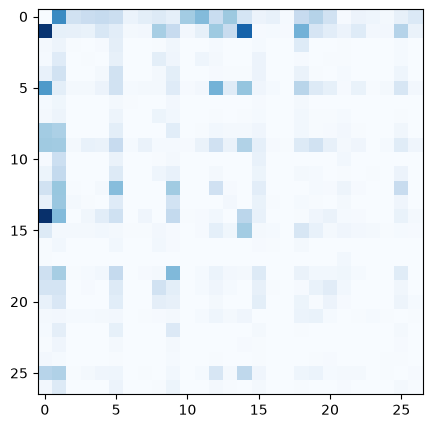

In [15]:
# Bi-gram matrix
plt.figure(figsize=(5, 5))
plt.imshow(bigram_cnt_tensor, cmap="Blues")
plt.show()

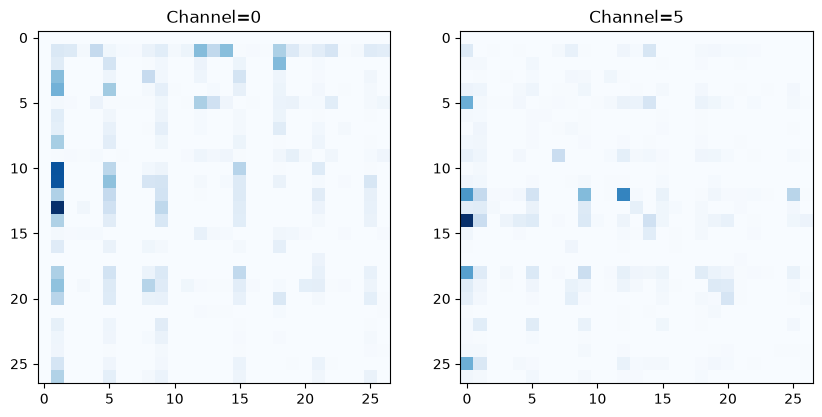

In [16]:
# Tri-gram matrix for 2 channel
plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.imshow(trigram_cnt_tensor[0], cmap="Blues")
plt.title("Channel=0")
plt.subplot(1, 2, 2)
plt.imshow(trigram_cnt_tensor[5], cmap="Blues")
plt.title("Channel=5")
plt.show()

# **N-Gram Count Tensor to N-Gram Probability Tensor**

- For a bi-gram model: we have a 27 X 27 tensor
    - We are interested in calculating p(c_t|c_t-1)
    - For this we need to compute probability of over all possible c_t's given a fixed c_t-1
    - This maps to normalizing the bi-gram count tensor along dim=1 -> that is for each row compute sum across all columns
    - P = N / N.sum(dim=1, keepdim=True)

- For a tri-gram model: we have a 27 X 27 X 27 tensor
    - We are interested in calculating p(c_t|c_t-1, c_t-2)
    - For this we need to compute probability of over all possible c_t's given a fixed combination of c_t-1, c_t-2
    - This maps to normalizing the bi-gram count tensor along dim=2 -> that is for each channel X row combination, compute sum across all columns
    - P = N / N.sum(dim=2, keepdim=True)

- In general, for a n-gram model:
    - P = N / N.sum(dim=-1, keepdim=True)

In [17]:
def get_ngram_prob_tensor(N:torch.Tensor, alpha:float=0)->torch.Tensor:
    P = N.float()
    P = P / (P.sum(dim=-1, keepdim=True)+alpha)
    return P

bigram_prob_tensor = get_ngram_prob_tensor(bigram_cnt_tensor)
trigram_prob_tensor = get_ngram_prob_tensor(trigram_cnt_tensor)

In [18]:
# Notice the nan in the trigram_prob_tensor -> 
# That essentially maps to the following case: p(c_t|'.', '.') -> Since '.','.' never appears in corpus, we have nans
# We can use smoothing techniques to resolve this

print(bigram_prob_tensor.sum(dim=1))
print('-'*100)
print(trigram_prob_tensor.sum(dim=2))

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
----------------------------------------------------------------------------------------------------
tensor([[   nan, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [   nan, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [   nan, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,    nan,    nan, 1.0000,
         1.0000, 1.0000,    nan, 1.0000,    nan, 1.0000, 1.0000,    nan,    nan,
        

# **Sampling from N-Gram model**

In [19]:
# Sample from bi-gram model

g = torch.Generator().manual_seed(42)

for i in range(10):
    out = ['.']
    while True:
        context_char = out[-1]
        context_idx = stoi[context_char]
        model_op_idx =torch.multinomial(bigram_prob_tensor[context_idx], num_samples=1, replacement=True, generator=g).item()
        model_op_char = itos[model_op_idx]
        out.append(model_op_char)
        if model_op_char=='.':
            break

    print(''.join(out))

.anugeenvi.
.s.
.mabian.
.dan.
.stan.
.silaylelaremah.
.li.
.le.
.epiachalen.
.diza.


## **Generic Sampling Method for N-Gram model**

In [20]:
# For generic n-gram model:

# We need to create an initial context
# For example, 
# For a 2-gram model, intial context length is 1 and we have '.'
# For a 3-gram model, intial context length is 2 and we have '.' and <need_1_more>
# For a 4-gram model, intial context length is 2 and we have '.' and <need_2_more>
# We will create this initial context by sampling from the unigram distribution

In [21]:
# Unigram distribution
all_names = ''.join(names)
unigram_dict = {}
for char in all_names:
    unigram_dict[char] = unigram_dict.get(char, 0) + 1

unigram_lst = sorted([(k, v) for k,v in unigram_dict.items()])
unigram_cnt = torch.zeros(27, dtype=torch.int32)
for tup in unigram_lst:
    unigram_cnt[stoi[tup[0]]] = tup[1]
unigram_prob = unigram_cnt.float()
unigram_prob /= unigram_prob.sum()
unigram_prob

tensor([0.0000, 0.1728, 0.0135, 0.0180, 0.0280, 0.1041, 0.0046, 0.0098, 0.0388,
        0.0903, 0.0148, 0.0257, 0.0712, 0.0339, 0.0935, 0.0405, 0.0052, 0.0014,
        0.0648, 0.0413, 0.0284, 0.0160, 0.0131, 0.0047, 0.0036, 0.0498, 0.0122])

In [22]:
# Sampling Method scalable to any ngram model
def get_samples_from_ngram_model(P_ngram:torch.Tensor, P_1gram:torch.Tensor, ngram_cnt:int, stoi:dict, itos:dict, sample_cnt:int=10)->List:
    
    g = torch.Generator().manual_seed(42)
    samples = []

    for i in range(sample_cnt):
        
        # Create init context from 1-gram prob
        out=['.']

        init_context = ngram_cnt-2
        while init_context>0:
            unigram_op_idx = torch.multinomial(P_1gram, num_samples=1, replacement=True, generator=g).item()
            unigram_op_char = itos[unigram_op_idx]
            out.append(unigram_op_char)
            init_context-=1
        
        # Generate from n-gram prob
        while True:
            context_chars_lst = out[-(ngram_cnt-1):]
            context_idx_lst = [stoi[char] for char in context_chars_lst]
            model_op_idx =torch.multinomial(P_ngram[tuple(context_idx_lst)], num_samples=1, replacement=True, generator=g).item()
            model_op_char = itos[model_op_idx]
            out.append(model_op_char)
            if model_op_char=='.':
                break
    
        samples.append(''.join(out))

    return samples
    

        
# Bi-Gram Sampling
ngram_cnt=2
result = get_samples_from_ngram_model(bigram_prob_tensor, unigram_prob, 2, stoi, itos)
print(f"{ngram_cnt}-gram samples:\n", result)

print('-'*120)
# Tri-Gram Sampling
trigram_prob_tensor = get_ngram_prob_tensor(trigram_cnt_tensor, alpha=1e-3)
ngram_cnt=3
result = get_samples_from_ngram_model(trigram_prob_tensor, unigram_prob, 3, stoi, itos)
print(f"{ngram_cnt}-gram samples:\n", result)


2-gram samples:
 ['.anugeenvi.', '.s.', '.mabian.', '.dan.', '.stan.', '.silaylelaremah.', '.li.', '.le.', '.epiachalen.', '.diza.']
------------------------------------------------------------------------------------------------------------------------
3-gram samples:
 ['.anuee.', '.nat.', '.syna.', '.idushante.', '.na.', '.silayley.', '.otter.', '.lucin.', '.epiah.', '.nasilanzi.']


# **Quantifying Perfomance of N-Gram model**

- We will create ngrams from the training data which was itself used to form the n-gram probabilities
- Now for all the generated ngrams from training data, using the ngram prob table, we can get the prob/likelihood of the training data
- The performance of a model is good if the likelihood of the training data is high
- We can quantify the likelihood or equivalently the negative log-likelihood of the training data for the bigram, trigram or the ngram model
- The lower the NLL metric, the better will be the performance of the ngram model from the context of language modelling

In [23]:
# NLL computation of the bigram model over all the bigrams from the 1st 3 names
total_nll = 0
cnt_ngrams = 0
for name in names[:3]:
    lst_ngrams = generate_ngrams_v2(name, 2)
    lst_ngrams_idx = [tuple(stoi[char] for char in tup) for tup in lst_ngrams]
    lst_ngrams_prob = torch.tensor([bigram_prob_tensor[ngram_idx] for ngram_idx in lst_ngrams_idx])
    lst_ngrams_logprob = torch.log(lst_ngrams_prob)
    total_nll += (-1)*lst_ngrams_logprob.sum().item()
    cnt_ngrams += len(lst_ngrams_logprob)
    for i in range(len(lst_ngrams)):
        print(f"{lst_ngrams[i]} -> {lst_ngrams_idx[i]} -> {lst_ngrams_prob[i].item():.4f} -> {lst_ngrams_logprob[i].item():.4f}")
    print('-'*50)
print(f"Sum of NLL: {total_nll}")
print(f"Count of terms over which NLL sum is computed: {cnt_ngrams}")
print(f"Normalized NLL: {(total_nll/cnt_ngrams):.4f}")

('.', 'e') -> (0, 5) -> 0.0478 -> -3.0408
('e', 'm') -> (5, 13) -> 0.0377 -> -3.2793
('m', 'm') -> (13, 13) -> 0.0253 -> -3.6772
('m', 'a') -> (13, 1) -> 0.3899 -> -0.9418
('a', '.') -> (1, 0) -> 0.1960 -> -1.6299
--------------------------------------------------
('.', 'o') -> (0, 15) -> 0.0123 -> -4.3982
('o', 'l') -> (15, 12) -> 0.0780 -> -2.5508
('l', 'i') -> (12, 9) -> 0.1777 -> -1.7278
('i', 'v') -> (9, 22) -> 0.0152 -> -4.1867
('v', 'i') -> (22, 9) -> 0.3541 -> -1.0383
('i', 'a') -> (9, 1) -> 0.1381 -> -1.9796
('a', '.') -> (1, 0) -> 0.1960 -> -1.6299
--------------------------------------------------
('.', 'a') -> (0, 1) -> 0.1377 -> -1.9829
('a', 'v') -> (1, 22) -> 0.0246 -> -3.7045
('v', 'a') -> (22, 1) -> 0.2495 -> -1.3882
('a', '.') -> (1, 0) -> 0.1960 -> -1.6299
--------------------------------------------------
Sum of NLL: 38.785637855529785
Count of terms over which NLL sum is computed: 16
Normalized NLL: 2.4241


In [24]:
# Generic function for NLL computation

def get_nll_ngram_model(lst_s:list, ngram_cnt:int, stoi:dict, P_ngram:torch.Tensor)->Tuple:
    total_nll = 0
    cnt_ngrams = 0

    for s in lst_s[:]:
        lst_ngrams = generate_ngrams_v2(s, ngram_cnt)
        lst_ngrams_idx = [tuple(stoi[char] for char in tup) for tup in lst_ngrams]
        lst_ngrams_prob = torch.tensor([P_ngram[ngram_idxs] for ngram_idxs in lst_ngrams_idx])
        lst_ngrams_logprob = torch.log(lst_ngrams_prob)
        total_nll += (-1)*lst_ngrams_logprob.sum().item()
        cnt_ngrams += len(lst_ngrams_logprob)
        # for i in range(len(lst_ngrams)):
        #     print(f"{lst_ngrams[i]} -> {lst_ngrams_idx[i]} -> {lst_ngrams_prob[i].item():.4f} -> {lst_ngrams_logprob[i].item():.4f}")
        # print('-'*50)
    
    return total_nll, cnt_ngrams


list_of_names = names[:]
ngram_cnt=2
total_nll, cnt_ngrams = get_nll_ngram_model(list_of_names, ngram_cnt, stoi, bigram_prob_tensor)
print(f'{ngram_cnt}-gram model NLL loss:')
print(f"Sum of NLL: {total_nll}")
print(f"Count of terms over which NLL sum is computed: {cnt_ngrams}")
print(f"Normalized NLL: {(total_nll/cnt_ngrams):.4f}")

print('-'*50)
list_of_names = names[:]
ngram_cnt=3
total_nll, cnt_ngrams = get_nll_ngram_model(list_of_names, ngram_cnt, stoi, trigram_prob_tensor)
print(f'{ngram_cnt}-gram model NLL loss:')
print(f"Sum of NLL: {total_nll}")
print(f"Count of terms over which NLL sum is computed: {cnt_ngrams}")
print(f"Normalized NLL: {(total_nll/cnt_ngrams):.4f}")


2-gram model NLL loss:
Sum of NLL: 559873.5914511681
Count of terms over which NLL sum is computed: 228146
Normalized NLL: 2.4540
--------------------------------------------------
3-gram model NLL loss:
Sum of NLL: 404358.53575491905
Count of terms over which NLL sum is computed: 196113
Normalized NLL: 2.0619



# **N-Gram Models vs Neural Language Models**

## **Common Goal**

Both N-Gram models and Neural Language Models (NLMs) estimate the probability of the next token given previous tokens:

$$
P(\text{token}_{t} \mid \text{token}_{1}, \text{token}_{2}, \ldots, \text{token}_{t-1})
$$

---

## **N-Gram Models (Count-Based)**

### **Assumption**

Only the previous $n-1$ tokens matter:

$$
P(\text{token}_{t} \mid \text{token}_{1}, \ldots, \text{token}_{t-1})
\approx
P(\text{token}_{t} \mid \text{token}_{t-(n-1)}, \ldots, \text{token}_{t-1})
$$

**Examples:**

- **Bigram:**

$$
P(\text{token}_{t} \mid \text{token}_{t-1})
$$

- **Trigram:**

$$
P(\text{token}_{t} \mid \text{token}_{t-2}, \text{token}_{t-1})
$$

### **Training**

No explicit optimization or gradient descent. Probabilities are estimated directly from counts:

$$
P(w_{t} \mid \text{context})
=
\frac{\text{Count}(\text{context}, w_{t})}{\text{Count}(\text{context})}
$$

### **Characteristics**

- Fixed context length ($n-1$)
- Essentially a large lookup table
- Requires storing count tensors of size $V^{n}$, where $V$ is vocabulary size
- Suffers from data sparsity (unseen n-grams have zero counts unless smoothing is used)

---

## **Neural Language Models (Learned Function Approximation)**

Instead of storing counts, a neural network learns a function:

$$
P(\text{token}_{t} \mid \text{context}) = f_{\theta}(\text{context})
$$

where $\theta$ are trainable parameters.

### **Training**

Explicit optimization:

1. Forward pass
2. Compute cross-entropy loss
3. Backpropagation
4. Gradient descent

### **Characteristics**

- Learns probabilities from parameters rather than counts
- May/Maynot use variable-length context (Does not always need to be a fixed length context like a ngram model: context_length=1 for bigram, context_length=2 for trigram)
- Generalizes to unseen sequences through embeddings and learned representations
- Parameter count does not grow exponentially with context length

---

## **Relationship Between N-Grams and Neural LMs**

A neural LM can be viewed as a learned, compressed version of an n-gram model.

### **Example1:** Autoregressive Decoder based Transformer

### **Example2:** Neural Bigram Model (1-Layer NN)

Implemented as:

$$
P(\text{token}_{t} \mid \text{token}_{t-1}) = \text{softmax}\big(W[\text{token}_{t-1}]\big)
$$

where $W$ is learned during training.

So a neural network can be trained to behave like a bigram model, but with learned parameters instead of count tables.

#### *Example2: Forward Pass*
| Step | Description | Shape |
|:----:|-------------|:-----:|
| 1 | **Input** — one-hot encode $\text{token}_{t-1}$ as $x$ | $(1 \times V)$ |
| 2 | **Linear layer** — weight matrix $W$ | $(V \times V)$ |
| 3 | **Logits** (pre-softmax) — $x W^\top$ | $(1 \times V)$ |
| 4 | **Probabilities** (post-softmax) — $P(\text{token}_{t} \mid \text{token}_{t-1})$ | $(1 \times V)$ |
Where $V$ is vocabulary size.


### **Example 3:** Neural Trigram Model (1-Layer NN)

A trigram model conditions on the previous **two** tokens:

$$
P(\text{token}_{t} \mid \text{token}_{t-2}, \text{token}_{t-1})
$$

**Implementation** — concatenate one-hot encodings of both context tokens, then apply a linear layer + softmax:

$$
P(\text{token}_{t} \mid \text{token}_{t-2}, \text{token}_{t-1})
= \text{softmax}\!\left(x \, W^\top\right)
$$

where

$$
x = \text{concat}\!\left(
  \text{one-hot}(\text{token}_{t-2}),\;
  \text{one-hot}(\text{token}_{t-1})
\right) \in \mathbb{R}^{1 \times 2V}
$$

and $W \in \mathbb{R}^{V \times 2V}$ is learned during training.

Like the bigram case, this behaves like a trigram count table, but with learned parameters instead of stored counts.

#### *Example3: Forward Pass*

| Step | Description | Shape |
|:----:|-------------|:-----:|
| 1 | **Input** — concat one-hot $\text{token}_{t-2}$ and $\text{token}_{t-1}$ as $x$ | $(1 \times 2V)$ |
| 2 | **Linear layer** — weight matrix $W$ | $(V \times 2V)$ |
| 3 | **Logits** (pre-softmax) — $x W^\top$ | $(1 \times V)$ |
| 4 | **Probabilities** (post-softmax) — $P(\text{token}_{t} \mid \text{token}_{t-2}, \text{token}_{t-1})$ | $(1 \times V)$ |

Where $V$ is vocabulary size.

---

## **Key Difference**

| N-Gram Model | Neural Language Model |
|---|---|
| Previous tokens → count table → probability | Previous tokens → neural network → probability |
| Stores $O(V^{n})$ counts | Stores $O(\|\theta\|)$ parameters |
| No generalization to unseen n-grams | Generalizes via shared embeddings |


# **BiGram Neural Language Model: 1 Layer NN**




In [25]:
# Training data for bigrams: 
# x: 1st token --> y: 2nd token
xs, ys = [], []

for name in names[:]:
    lst_bigrams = generate_ngrams_v2(name, 2)
    for bigram in lst_bigrams:
        xs.append(stoi[bigram[0]])
        ys.append(stoi[bigram[1]])

xs = torch.tensor(xs)
ys = torch.tensor(ys)
print('xs.shape:', xs.shape)
print('ys.shape:', ys.shape)

xs.shape: torch.Size([228146])
ys.shape: torch.Size([228146])


xenc.shape: torch.Size([228146, 27])
yenc.shape: torch.Size([228146, 27])
------------------------------------------------------------------------------------------------------------------------


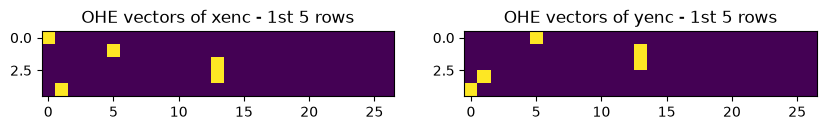

In [26]:
# Encode integers to OHE vectors
xenc = F.one_hot(xs, num_classes=len(stoi.keys())).float()
yenc = F.one_hot(ys, num_classes=len(stoi.keys())).float()
print('xenc.shape:', xenc.shape)
print('yenc.shape:',yenc.shape)

print('-'*120)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(xenc[:5, :])
plt.title("OHE vectors of xenc - 1st 5 rows")
plt.subplot(1, 2, 2)
plt.imshow(yenc[:5, :])
plt.title("OHE vectors of yenc - 1st 5 rows")
plt.show()

In [27]:
# Defining NN layer
g = torch.Generator().manual_seed(42)
W = torch.randn(len(stoi.keys()), len(stoi.keys()), generator=g)
print(W.shape)

torch.Size([27, 27])


logits.shape: torch.Size([228146, 27])
ypred.shape: torch.Size([228146, 27])
------------------------------------------------------------------------------------------------------------------------


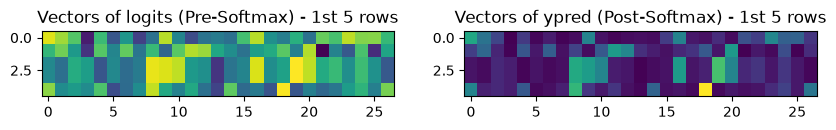

In [28]:
# Forward Pass:
# (B, 27) @ (27, 27) -> (B, 27)
logits = xenc @ W
counts = logits.exp()
ypred = counts/counts.sum(dim=-1, keepdim=True)

print('logits.shape:', logits.shape)
print('ypred.shape:', ypred.shape)

print('-'*120)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(logits[:5, :])
plt.title("Vectors of logits (Pre-Softmax) - 1st 5 rows")
plt.subplot(1, 2, 2)
plt.imshow(ypred[:5, :])
plt.title("Vectors of ypred (Post-Softmax) - 1st 5 rows")
plt.show()

# **Tensor Indexing & Slicing Cheat Sheet**

Assume a 2D tensor `arr` with shape `(4, 4)`:

```text
       col
       0   1   2   3

row 0  10  11  12  13
row 1  20  21  22  23
row 2  30  31  32  33
row 3  40  41  42  43
```

---

## **Core Mental Model**

For a 2D tensor, indexing follows:

```python
tensor[row_selector, col_selector]
```

**Think in two steps:**
1. Select rows
2. Select columns

---

## **Rule 1: Integer Indexing Removes Dimensions**

| Expression   | Result             | Shape  |
|:-------------|:-------------------|:-------|
| `arr[2]`     | `[30, 31, 32, 33]` | `(4,)` |
| `arr[2, 1]`  | `31`               | `()`   |

> **Memory:** Integer index → dimension disappears

---

## **Rule 2: Slice Indexing Preserves Dimensions**

| Expression   | Result               | Shape    |
|:-------------|:---------------------|:---------|
| `arr[2:3]`   | `[[30, 31, 32, 33]]` | `(1, 4)` |
| `arr[1:3]`   | rows 1 and 2         | `(2, 4)` |

> **Memory:** Slice → dimension remains

---

## **Rule 3: Colon (`:`) Means "Everything"**

| Expression   | Meaning              |
|:-------------|:---------------------|
| `arr[:, 2]`  | all rows, column 2   |
| `arr[2, :]`  | row 2, all columns   |
| `arr[:, :]`  | entire tensor        |

---

## **Continuous Submatrix Extraction**

**Goal** — extract:

```text
21  22
31  32
```

Rows `1, 2` and columns `1, 2` are **contiguous**, so use **slicing**:

```python
arr[1:3, 1:3]
```

**Result:**

```text
21  22
31  32
```

**Shape:** `(2, 2)`

**Visualization:**

```text
       0   1   2   3

0      10  11  12  13
1      20 [21  22] 23
2      30 [31  32] 33
3      40  41  42  43
```

> **Memory:** Continuous rectangular block → use slicing

---

## **Non-Continuous Submatrix Extraction**

**Goal** — extract:

```text
20  22
40  42
```

- **Rows:** `[1, 3]`
- **Columns:** `[0, 2]`

Rows and columns are **not contiguous** → slicing alone won't work.

---

### **What Beginners Expect (Wrong)**

Many people write:

```python
arr[[1, 3], [0, 2]]
```

expecting:

```text
20  22
40  42        # shape (2, 2)  ← WRONG expectation
```

---

### **Pairwise Indexing (What PyTorch Actually Does)**

PyTorch interprets:

```python
arr[[1, 3], [0, 2]]
```

as **coordinate pairs**:

```text
(1, 0)  →  20
(3, 2)  →  42
```

Equivalent to `zip([1, 3], [0, 2])` — **not** all row–column combinations.

**Result:** `[20, 42]` — **Shape:** `(2,)`

**Visualization:**

```text
       0   1   2   3

0      10  11  12  13
1     [20] 21  22  23
2      30  31  32  33
3      40  41 [42] 43
```

> **Memory:** Multiple index lists = pairwise coordinates = `zip(rows, cols)` — **NOT** a submatrix

---

### **Correct Two-Step Extraction**

**Goal:** same `20  22 / 40  42` submatrix.

**Step 1 — select rows `[1, 3]`:**

```python
arr[[1, 3], :]
```

```text
20  21  22  23
40  41  42  43
```

**Shape:** `(2, 4)`

**Step 2 — select columns `[0, 2]` from the result:**

```python
arr[[1, 3], :][:, [0, 2]]
```

```text
20  22
40  42
```

**Shape:** `(2, 2)`

**Visualization:**

```text
Original          →    Keep cols 0 and 2

20  21  22  23         20  22
40  41  42  43         40  42
```

> **Memory:** Non-continuous submatrix → rows first, then columns — **NOT** `arr[[rows], [cols]]`

---

## **Continuous vs Non-Continuous — Quick Reference**

| Type | Example target | Rows | Cols | Method |
|:-----|:---------------|:-----|:-----|:-------|
| **Continuous** | `21 22 / 31 32` | `1, 2` | `1, 2` | Slicing: `arr[1:3, 1:3]` |
| **Non-continuous** | `20 22 / 40 42` | `1, 3` | `0, 2` | Rows first, then columns |

**Why:**
- **Continuous** — rows and columns form one rectangular block → slice
- **Non-continuous** — rows/columns are scattered → two-step advanced indexing

---

## **Shape Rules Summary**

| Index type | Effect on shape | Example |
|:-----------|:----------------|:--------|
| **Integer** | Removes dimension | `(4, 4)` → `(4,)` via `arr[2]` |
| **Slice** | Preserves dimension | `(4, 4)` → `(1, 4)` via `arr[2:3]` |
| **List** | Dimension size = list length | `(4, 4)` → `(2, 4)` via `arr[[1, 3]]` |

---

## **Most Important Interview Gotcha**

These are **NOT** equivalent:

| Code | Result | Shape | Meaning |
|:-----|:-------|:------|:--------|
| `arr[[1, 3], [0, 2]]` | `[20, 42]` | `(2,)` | Pairwise coordinate selection |
| `arr[[1, 3], :][:, [0, 2]]` | `[[20, 22], [40, 42]]` | `(2, 2)` | True submatrix extraction |

---

## **Final Memory Rules**

1. **Integer index** → removes dimension
2. **Slice** → preserves dimension
3. **`:`** → everything along that axis
4. **Continuous submatrix** → slicing (`arr[r0:r1, c0:c1]`)
5. **Non-continuous submatrix** → rows first, then columns
6. **Multiple index lists** → pairwise coordinates — **NOT** a submatrix

In [30]:
# Implement Batch Grad Descent (BGD)
total_examples=xenc.shape[0]
num_epochs = 50
lr=1
loss_register_bgd = []

g = torch.Generator().manual_seed(42)

# Initialize model weights
W = torch.randn(len(stoi.keys()), len(stoi.keys()), generator=g, requires_grad=True)

for epoch in range(num_epochs):

    # Start from zero loss
    total_loss_batch = 0
    cnt_samples = total_examples

    # Perform Forward pass
    logits_batch = xenc @ W
    counts_batch = logits_batch.exp()
    ypred_batch = counts_batch/counts_batch.sum(dim=-1, keepdim=True)

    # Compute loss: Pairwise indexing
    nll_loss = ((-1)*ypred_batch[torch.arange(total_examples), ys].log()).mean()
    reg_loss = 0
    total_loss_batch = nll_loss + 0.1*reg_loss

    #Backward Pass: Set grads to zero to prevent grad accumulation
    W.grad=None
    total_loss_batch.backward()

    #Weights Update:
    W.data=W.data-lr*W.grad

    # Loss Registry for epoch
    loss_register_bgd.append(total_loss_batch.item())
    print(f"Epoch: {epoch+1}/{num_epochs}, Norm_Loss:{total_loss_batch:4f}")

print('-'*100)
print(f"Final loss after {num_epochs} epochs: {loss_register_bgd[-1]:4f}")
print('-'*100)


Epoch: 1/50, Norm_Loss:3.696648
Epoch: 2/50, Norm_Loss:3.689071
Epoch: 3/50, Norm_Loss:3.681566
Epoch: 4/50, Norm_Loss:3.674131
Epoch: 5/50, Norm_Loss:3.666768
Epoch: 6/50, Norm_Loss:3.659472
Epoch: 7/50, Norm_Loss:3.652244
Epoch: 8/50, Norm_Loss:3.645082
Epoch: 9/50, Norm_Loss:3.637985
Epoch: 10/50, Norm_Loss:3.630953
Epoch: 11/50, Norm_Loss:3.623983
Epoch: 12/50, Norm_Loss:3.617075
Epoch: 13/50, Norm_Loss:3.610229
Epoch: 14/50, Norm_Loss:3.603441
Epoch: 15/50, Norm_Loss:3.596713
Epoch: 16/50, Norm_Loss:3.590042
Epoch: 17/50, Norm_Loss:3.583429
Epoch: 18/50, Norm_Loss:3.576872
Epoch: 19/50, Norm_Loss:3.570370
Epoch: 20/50, Norm_Loss:3.563922
Epoch: 21/50, Norm_Loss:3.557528
Epoch: 22/50, Norm_Loss:3.551188
Epoch: 23/50, Norm_Loss:3.544898
Epoch: 24/50, Norm_Loss:3.538661
Epoch: 25/50, Norm_Loss:3.532473
Epoch: 26/50, Norm_Loss:3.526336
Epoch: 27/50, Norm_Loss:3.520247
Epoch: 28/50, Norm_Loss:3.514207
Epoch: 29/50, Norm_Loss:3.508215
Epoch: 30/50, Norm_Loss:3.502270
Epoch: 31/50, Norm_

In [31]:
# Implement MiniBatch Grad Descent (MBGD)
total_examples=16
minibatch_sampling_prob = torch.tensor([(1/total_examples)]*total_examples)
batch_size=4
num_epochs = 3

g = torch.Generator().manual_seed(42)
for i in range(num_epochs):
    sample_idxs = torch.multinomial(minibatch_sampling_prob, num_samples=total_examples, replacement=False, generator=g)
    print(f"Epoch: {i+1}/{num_epochs}")
    print('-'*20)
    print('sample_idxs:\n', sample_idxs)
    for i in range(0, len(sample_idxs), batch_size):
        print(sample_idxs[i:i+batch_size])
    print('-'*100)

Epoch: 1/3
--------------------
sample_idxs:
 tensor([ 3,  0,  1,  8,  2,  9, 10, 11, 14,  5,  4, 15, 12, 13,  7,  6])
tensor([3, 0, 1, 8])
tensor([ 2,  9, 10, 11])
tensor([14,  5,  4, 15])
tensor([12, 13,  7,  6])
----------------------------------------------------------------------------------------------------
Epoch: 2/3
--------------------
sample_idxs:
 tensor([ 8,  9,  4,  0, 13, 11, 15, 14, 12,  7,  6,  3,  2,  5,  1, 10])
tensor([8, 9, 4, 0])
tensor([13, 11, 15, 14])
tensor([12,  7,  6,  3])
tensor([ 2,  5,  1, 10])
----------------------------------------------------------------------------------------------------
Epoch: 3/3
--------------------
sample_idxs:
 tensor([ 5, 15,  9,  0, 11,  6,  1, 14, 10,  7,  3,  2, 13,  4,  8, 12])
tensor([ 5, 15,  9,  0])
tensor([11,  6,  1, 14])
tensor([10,  7,  3,  2])
tensor([13,  4,  8, 12])
----------------------------------------------------------------------------------------------------


In [32]:
# Training Loop with MBGD
total_examples=xenc.shape[0]
minibatch_sampling_prob = torch.tensor([(1/total_examples)]*total_examples)
batch_size=int(228146/32)
# batch_size=32
num_epochs = 50
lr=1
loss_register_mbgd = []

g = torch.Generator().manual_seed(42)

# Initialize model weights
W = torch.randn(len(stoi.keys()), len(stoi.keys()), generator=g, requires_grad=True)

# Training Loop

for epoch in range(num_epochs):

    # Start from zero loss
    loss = 0
    cnt_samples = 0

    # Reorder sample idxs for epoch
    batch_idxs = torch.multinomial(minibatch_sampling_prob, num_samples=total_examples, replacement=False, generator=g)

    for i in range(0, total_examples, batch_size):
        # Prepare minibatch indexes
        minibatch_idxs = batch_idxs[i:i+batch_size]

        # Get hold of samples at the minibatch indexes (ip/op pairs)
        xenc_minibatch = xenc[minibatch_idxs]
        labels = ys[minibatch_idxs]

        # print(minibatch_idxs.shape)
        # print(labels.shape)

        # Perform Forward pass
        logits_minibatch = xenc_minibatch @ W
        counts_minibatch = logits_minibatch.exp()
        ypred_minibatch = counts_minibatch/counts_minibatch.sum(dim=-1, keepdim=True)

        # Compute loss: Pairwise indexing
        nll_loss = ((-1)*ypred_minibatch[torch.arange(len(minibatch_idxs)), labels].log()).mean()
        reg_loss = 0
        total_loss_minibatch = nll_loss + 0.1*reg_loss

        #Backward Pass: Set grads to zero to prevent grad accumulation
        W.grad=None
        total_loss_minibatch.backward()

        #Weights Update:
        W.data=W.data-lr*W.grad

        # Loss Registry for minibatch
        loss += total_loss_minibatch.item()*len(minibatch_idxs)
        cnt_samples += len(minibatch_idxs)

    # Loss Registry for epoch
    normalized_loss = (loss/cnt_samples)
    loss_register_mbgd.append(normalized_loss)
    print(f"Epoch: {epoch+1}/{num_epochs}, Loss:{loss}, cnt_samples: {cnt_samples}, Norm_Loss:{normalized_loss:4f}")

print('-'*100)
print(f"Final loss after {num_epochs} epochs: {loss_register_mbgd[-1]:4f}")
print('-'*100)

Epoch: 1/50, Loss:818864.3472421169, cnt_samples: 228146, Norm_Loss:3.589212
Epoch: 2/50, Loss:774671.482915163, cnt_samples: 228146, Norm_Loss:3.395508
Epoch: 3/50, Loss:740458.6606769562, cnt_samples: 228146, Norm_Loss:3.245547
Epoch: 4/50, Loss:713656.234773159, cnt_samples: 228146, Norm_Loss:3.128068
Epoch: 5/50, Loss:693079.7641713619, cnt_samples: 228146, Norm_Loss:3.037878
Epoch: 6/50, Loss:676661.7270636559, cnt_samples: 228146, Norm_Loss:2.965915
Epoch: 7/50, Loss:663524.448417902, cnt_samples: 228146, Norm_Loss:2.908333
Epoch: 8/50, Loss:652921.4667971134, cnt_samples: 228146, Norm_Loss:2.861858
Epoch: 9/50, Loss:643859.757570982, cnt_samples: 228146, Norm_Loss:2.822139
Epoch: 10/50, Loss:636343.1027579308, cnt_samples: 228146, Norm_Loss:2.789192
Epoch: 11/50, Loss:630060.6067712307, cnt_samples: 228146, Norm_Loss:2.761655
Epoch: 12/50, Loss:624624.3256466389, cnt_samples: 228146, Norm_Loss:2.737827
Epoch: 13/50, Loss:619957.0798192024, cnt_samples: 228146, Norm_Loss:2.717370

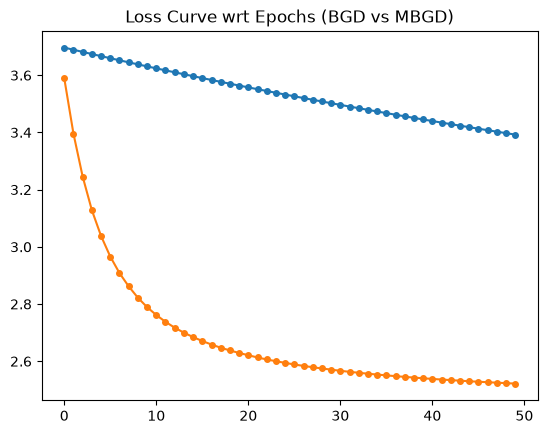

In [33]:
# Plot Loss
plt.plot(loss_register_bgd, marker='o', markersize=4)
plt.plot(loss_register_mbgd, marker='o', markersize=4)
plt.title("Loss Curve wrt Epochs (BGD vs MBGD)")
plt.show()